# LIME diverse-budget tuning — Autolycus-LIME vs ours

For each `(dataset, target model)` we sweep the query budget and compare **Autolycus base-LIME**
against **our LIME attack** (boundary search + LIME-threshold diverse generation) at several
**diverse budgets**.

**The diverse-budget knob.** Phase-1 generates `n_div = clip(Q*div_frac, 0, div_cap)` diverse
samples. At useful budgets `Q*div_frac` exceeds the cap, so the **cap** (`div_cap` = max diverse
samples) is the knob that actually binds — that is what we tune. `cap=0` disables diverse entirely
(boundary-only). `div_frac` is held fixed and only protects very small `Q` from starvation.
(These were hardcoded `0.15 / 10` in `traverse_explanations_LIME3`; now exposed as parameters.)

**LIME convention:** `n = size = 3` seeds/class, `k = nfe = 1` top feature.

**X-axis = query budget** (Autolycus convention). Each traverse also records its real query count; base-LIME often
empties its queue well before the cap (few seeds), so its curve stops early while ours keeps
saturates below the budget, so its curve goes flat while ours keeps rising with budget.

**Protocol.** Surrogate fidelity = MEAN over refits (no argmax/test-set selection). Paired sample
sets across all arms; per-set reseeding ⇒ nested Q-sweep. Paired Wilcoxon (ours@best-cap vs base)
at the top budget. Self-contained: only project import is `attack_utils`.

## 0. Engine — Autolycus vs ours at several diverse budgets

Identical logic to `lime_paper_run.py` (the parallel CLI); inlined so the notebook stands alone.

In [1]:
import os, json, time, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import lime, lime.lime_tabular
from scipy.stats import wilcoxon

from attack_utils import (load_dataset, load_model, mega_sample_generation,
                          _fit_one_surrogate, traverse_explanations_LIME,
                          traverse_explanations_LIME3)   # the attack (unchanged)

DATASETS = {0: 'iris', 1: 'crop', 2: 'adult', 3: 'breast', 4: 'nursery', 5: 'mushroom'}
MODELS   = {0: 'DT', 1: 'LR', 2: 'NB', 3: 'KNN', 4: 'RF', 5: 'MLP'}
DEFAULT_MODELS = [1, 2, 3, 0, 4]
DIV_CAPS = [0, 5, 15, 30]
DIV_FRAC = 0.3
REPS = {'dt': 20, 'rdf': 10, 'nb': 1, 'lr': 1, 'knn': 1}
MODEL_DISP = {'lr': 'LR', 'nb': 'NB', 'knn': 'KNN', 'dt': 'DT', 'rdf': 'RF'}


def _fidelity(mname, V, P, t_model, Xt, n_classes):
    if mname == 'nb':
        V = np.clip(np.asarray(V, float), 0, None)
    P = np.asarray(P)
    ytar = t_model.predict(Xt)
    if len(np.unique(P)) < 2:
        # only one class among the traversed labels -> constant-predictor fidelity (avoids a
        # fit crash that would drop the whole cell).
        cls = P[0] if len(P) else 0
        return float(np.mean(ytar == cls))
    fids = []
    for k in range(REPS.get(mname, 1)):
        try:
            sm = _fit_one_surrogate(mname, np.asarray(V, float), P, n_classes, seed=k)
            fids.append(float(np.mean(ytar == sm.predict(Xt))))
        except Exception:
            fids.append(float('nan'))
    return float(np.nanmean(fids)) if fids else float('nan')


def _traverse(kind, seed_set, expl, t_model, mname, lb, ub, Q, args2, X_train, y_train, nfe,
              div_cap=10, div_frac=DIV_FRAC):
    if kind == 'base':
        return traverse_explanations_LIME(seed_set, expl, t_model, lb, ub, Q, nfe, args2)
    return traverse_explanations_LIME3(seed_set, expl, t_model, lb, ub, Q, nfe, args2,
                                       mname, X_train, y_train, use_diverse=(div_cap > 0),
                                       diverse_method='lime_threshold', div_frac=div_frac, div_cap=div_cap)


def run_dataset_divsweep(ds, models=DEFAULT_MODELS, q_list=(100, 250, 500, 1000),
                         div_caps=DIV_CAPS, div_frac=DIV_FRAC, hms=10, size=3, nfe=1,
                         seed=0, out_dir='.'):
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f'lime_divsweep_n{size}_k{nfe}_ds{ds}.json')
    warnings.filterwarnings('ignore')
    q_list = list(q_list); div_caps = list(div_caps)
    args1, args2 = load_dataset(ds)
    X_train, X_test, y_train, y_test, X_test_t, X_test_s, y_test_t, y_test_s = args1
    n_classes = args2[2]
    Xt = np.asarray(X_test_t.values, float)
    rows = []
    for m in models:
        mname = MODELS.get(m, str(m)); t0 = time.time()
        try:
            random.seed(seed); np.random.seed(seed)
            t_model, mname = load_model(m, X_train, y_train)
            expl = lime.lime_tabular.LimeTabularExplainer(X_train.values, discretize_continuous=True)
            mega = mega_sample_generation(X_test_s.to_numpy(), y_test_s, n_classes, [size], hms)
            base_fid = {Q: [] for Q in q_list}; base_q = {Q: [] for Q in q_list}
            ours_fid = {c: {Q: [] for Q in q_list} for c in div_caps}
            ours_q   = {c: {Q: [] for Q in q_list} for c in div_caps}
            for Q in q_list:
                lb = int((Q // n_classes) * 0.5 + 1); ub = int((Q // n_classes) * (n_classes + 0.5) + 1)
                for i in range(hms):
                    random.seed(seed + 1 + i); np.random.seed(seed + 1 + i)
                    V, P, nq = _traverse('base', mega[i][0], expl, t_model, mname, lb, ub, Q,
                                         args2, X_train, y_train, nfe)
                    base_fid[Q].append(_fidelity(mname, V, P, t_model, Xt, n_classes)); base_q[Q].append(int(nq))
                for c in div_caps:
                    for i in range(hms):
                        random.seed(seed + 1 + i); np.random.seed(seed + 1 + i)
                        V, P, nq = _traverse('ours', mega[i][0], expl, t_model, mname, lb, ub, Q,
                                             args2, X_train, y_train, nfe, div_cap=c, div_frac=div_frac)
                        ours_fid[c][Q].append(_fidelity(mname, V, P, t_model, Xt, n_classes)); ours_q[c][Q].append(int(nq))

            def _pack(fd, qd):
                return {'fid_mean': [round(float(np.mean(fd[Q])), 4) for Q in q_list],
                        'fid_std':  [round(float(np.std(fd[Q])), 4) for Q in q_list],
                        'fid_all':  [[round(x, 4) for x in fd[Q]] for Q in q_list],
                        'q_actual': [round(float(np.mean(qd[Q])), 1) for Q in q_list]}

            row = {'dataset': DATASETS[ds], 'model': mname, 'ds': ds, 'm': m,
                   'q_cap': q_list, 'div_caps': div_caps, 'div_frac': div_frac,
                   'hms': hms, 'size': size, 'nfe': nfe, 'seed': seed,
                   'base': _pack(base_fid, base_q),
                   'ours': {str(c): _pack(ours_fid[c], ours_q[c]) for c in div_caps},
                   'secs': round(time.time() - t0, 1)}
            topQ = q_list[-1]; bt = np.array(base_fid[topQ], float)
            best_c = max(div_caps, key=lambda c: float(np.mean(ours_fid[c][topQ])))
            L = np.array(ours_fid[best_c][topQ], float)
            row['best_div_cap_top'] = best_c
            row['delta_top_bestdiv'] = round(float(L.mean() - bt.mean()), 4)
            row['wilcoxon_p_bestdiv'] = (float(wilcoxon(L, bt).pvalue) if not np.allclose(L, bt) else 1.0)
        except Exception as e:
            traceback.print_exc()
            row = {'dataset': DATASETS[ds], 'model': mname, 'ds': ds, 'm': m,
                   'error': repr(e), 'secs': round(time.time() - t0, 1)}
        rows.append(row)
        print('ROWDONE', row['dataset'], row['model'], 'best_cap', row.get('best_div_cap_top'),
              'delta', row.get('delta_top_bestdiv'), 'secs', row['secs'], flush=True)
        with open(path, 'w') as f:
            json.dump(rows, f, indent=2)
    return rows

## 1. Config

In [2]:
from pathlib import Path
Q_LIST = [100, 250, 500, 1000]
DIV_CAPS = [0, 5, 15, 30]
DIV_CAP_FIXED = 15       # single fixed diverse budget for the paper figure (best global; no per-cell tuning)
DIV_FRAC = 0.3
HMS, SIZE, NFE, SEED = 10, 1, 3, 0   # LIME: n=1 sample/class, k=3 top features
RESULT_DIR = Path('paper_results')                              # all paper result data lives here
FIG_DIR    = Path(f'paper_results/lime_divsweep_n{SIZE}_k{NFE}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

HEADLINE = ['LR', 'NB', 'KNN']
APPENDIX = ['DT', 'RF']
DATASET_ORDER = ['crop', 'adult', 'breast', 'nursery', 'mushroom']
CAP_COLORS = {c: col for c, col in zip(DIV_CAPS, ['tab:orange', 'tab:green', 'tab:blue', 'tab:purple'])}

## 2. Load results (or run any missing datasets)

Set `run_missing=True` to compute a dataset whose JSON is absent (slow).

In [3]:
def load_or_run(size=SIZE, nfe=NFE, datasets=(1, 2, 3, 4, 5), models=DEFAULT_MODELS,
                q_list=Q_LIST, div_caps=DIV_CAPS, div_frac=DIV_FRAC, hms=HMS, seed=SEED,
                run_missing=False):
    rows = []
    for ds in datasets:
        p = RESULT_DIR / f'lime_divsweep_n{size}_k{nfe}_ds{ds}.json'
        if p.exists():
            rows += json.loads(p.read_text())
        elif run_missing:
            print('running', DATASETS[ds], '...')
            rows += run_dataset_divsweep(ds, models=list(models), q_list=q_list, div_caps=div_caps,
                                         div_frac=div_frac, hms=hms, size=size, nfe=nfe,
                                         seed=seed, out_dir=str(RESULT_DIR))
        else:
            print('MISSING (skipped):', p.name)
    return rows

sweep = load_or_run()
errs = [(r['dataset'], r['model']) for r in sweep if 'error' in r]
if errs:
    print('cells with errors:', errs)
sweep = [r for r in sweep if 'error' not in r]

recs = []
for r in sweep:
    disp = MODEL_DISP.get(r['model'], r['model'].upper())
    for qi, qc in enumerate(r['q_cap']):
        recs.append({'dataset': r['dataset'], 'model': disp, 'arm': 'base', 'cap': -1, 'q_cap': qc,
                     'q_actual': r['base']['q_actual'][qi], 'fid': r['base']['fid_mean'][qi],
                     'fid_std': r['base']['fid_std'][qi]})
        for c in r['div_caps']:
            o = r['ours'][str(c)]
            recs.append({'dataset': r['dataset'], 'model': disp, 'arm': 'ours', 'cap': c, 'q_cap': qc,
                         'q_actual': o['q_actual'][qi], 'fid': o['fid_mean'][qi], 'fid_std': o['fid_std'][qi]})
tidy = pd.DataFrame(recs)
META = {(MODEL_DISP.get(r['model'], r['model'].upper()), r['dataset']):
        (r.get('best_div_cap_top'), r.get('wilcoxon_p_bestdiv')) for r in sweep}
# raw, tidy plot data for re-plotting/recoloring: one row per (dataset, model, arm, cap, budget)
csv_path = RESULT_DIR / f'lime_divsweep_n{SIZE}_k{NFE}.csv'
tidy.to_csv(csv_path, index=False)
print(len(sweep), 'cells loaded; caps', DIV_CAPS, '; budgets', sorted(tidy.q_cap.unique()))
print('raw plot data (tidy CSV) ->', csv_path)
tidy.head()

25 cells loaded; caps [0, 5, 15, 30] ; budgets [25, 50, 100, 250, 500, 1000]
raw plot data (tidy CSV) -> paper_results/lime_divsweep_n1_k3.csv


,dataset,model,arm,cap,q_cap,q_actual,fid,fid_std
0,crop,LR,base,-1,100,101.0,0.4153,0.0778
1,crop,LR,ours,0,100,101.0,0.3635,0.0364
2,crop,LR,ours,5,100,101.0,0.3847,0.0338
3,crop,LR,ours,15,100,101.0,0.3710,0.0539
4,crop,LR,ours,30,100,101.0,0.3600,0.0691


## 3. Table — Autolycus vs ours (per diverse budget) at the top budget

In [4]:
def star(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return ''
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

# budgets are per-dataset (breast=100, others=1000), so each cell uses its OWN top budget
tidy['_is_top'] = tidy.groupby(['model', 'dataset'])['q_cap'].transform('max') == tidy['q_cap']
top = tidy[tidy['_is_top']].copy()

def show(models, title):
    print(f"\n=== {title}  (each cell at its top budget, {HMS} sets, n={SIZE}/class, k={NFE}, div_frac={DIV_FRAC}) ===")
    recs = []
    for mdl in models:
        for ds in DATASET_ORDER:
            sub = top[(top.model == mdl) & (top.dataset == ds)]
            if sub.empty:
                continue
            base = sub[sub.arm == 'base'].fid.iloc[0]
            row = {'model': mdl, 'dataset': ds, 'base': f"{base:.3f}"}
            for c in DIV_CAPS:
                v = sub[(sub.arm == 'ours') & (sub.cap == c)].fid
                row[f'cap{c}'] = (f"{v.iloc[0]:.3f}" if len(v) else '')
            bc, p = META.get((mdl, ds), (None, None))
            bestv = sub[(sub.arm == 'ours') & (sub.cap == bc)].fid
            row['best'] = f"cap{bc}"
            row['delta(best-base)'] = (f"{100*(bestv.iloc[0]-base):+.1f}{star(p)}" if len(bestv) else '')
            recs.append(row)
    print(pd.DataFrame(recs).set_index(['model', 'dataset']).to_string())

show(HEADLINE, 'HEADLINE: non-tree targets')
show(APPENDIX, 'APPENDIX: tree targets (near ceiling)')


=== HEADLINE: non-tree targets  (each cell at its top budget, 10 sets, n=1/class, k=3, div_frac=0.3) ===
                 base   cap0   cap5  cap15  cap30   best delta(best-base)
model dataset                                                            
LR    crop      0.805  0.824  0.846  0.859  0.869  cap30           +6.3**
      adult     0.790  0.767  0.760  0.755  0.750   cap0             -2.3
      breast    0.707  0.754  0.731  0.760  0.781  cap30             +7.4
      nursery   0.986  0.989  0.988  0.989  0.988   cap0             +0.3
      mushroom  0.803  0.885  0.874  0.860  0.871   cap0             +8.2
NB    crop      0.820  0.787  0.786  0.783  0.796  cap30             -2.4
      adult     0.832  0.613  0.884  0.952  0.955  cap30          +12.2**
      breast    0.839  0.925  0.920  0.908  0.887   cap0             +8.6
      nursery   0.839  0.896  0.892  0.892  0.896   cap0           +5.7**
      mushroom  0.688  0.790  0.781  0.794  0.795  cap30           +10.6*
KNN   

## 4. Diverse-budget tuning — fidelity gain over Autolycus vs diverse budget

For each `(dataset, model)` at the top budget: `Δ = ours@cap − base` in pp, vs the diverse budget
(`cap`). The peak of each curve is the best diverse budget for that target; `cap=0` = no diverse.
This is the figure to read when choosing the knob.

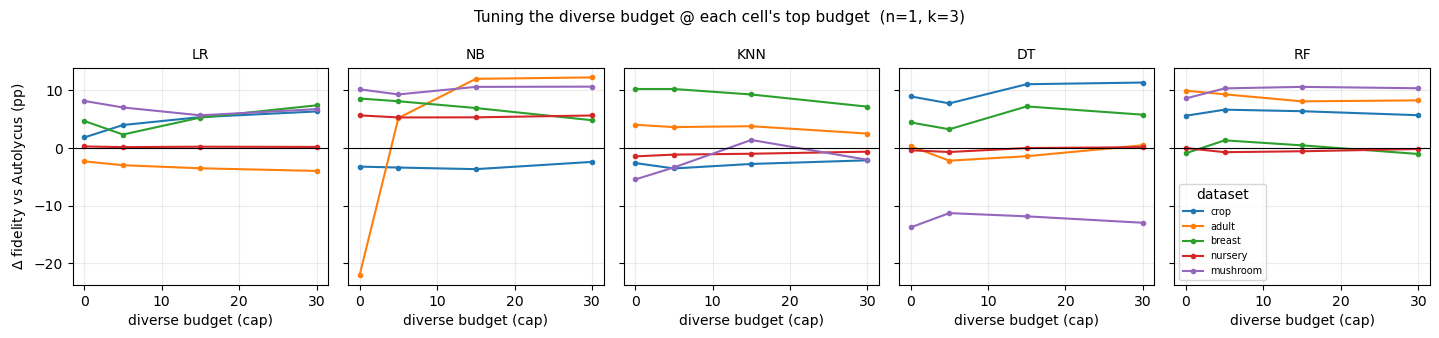

In [5]:
models_all = HEADLINE + APPENDIX
fig, axes = plt.subplots(1, len(models_all), figsize=(2.9 * len(models_all), 3.4),
                         squeeze=False, sharey=True)
for j, mdl in enumerate(models_all):
    ax = axes[0][j]
    for ds in DATASET_ORDER:
        sub = top[(top.model == mdl) & (top.dataset == ds)]
        if sub.empty:
            continue
        base = sub[sub.arm == 'base'].fid.iloc[0]
        caps = [c for c in DIV_CAPS if len(sub[(sub.arm == 'ours') & (sub.cap == c)])]
        y = [100 * (sub[(sub.arm == 'ours') & (sub.cap == c)].fid.iloc[0] - base) for c in caps]
        ax.plot(caps, y, '-o', ms=3, label=ds)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(mdl, fontsize=10); ax.set_xlabel('diverse budget (cap)'); ax.grid(alpha=0.25)
axes[0][0].set_ylabel(r'$\Delta$ fidelity vs Autolycus (pp)')
axes[0][-1].legend(fontsize=7, loc='best', title='dataset')
plt.suptitle(f'Tuning the diverse budget @ each cell\'s top budget  (n={SIZE}, k={NFE})', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'tuning_diverse_budget.png', dpi=140)
plt.show()

## 5. Query-budget curves — one panel per (dataset, model)

Base-LIME vs ours at each diverse budget, plotted against **query budget**. Saved to
`figures/lime_divsweep_n{SIZE}_k{NFE}/{dataset}_{model}.png`; headline models shown inline.

saved 25 curves to paper_results/lime_divsweep_n1_k3


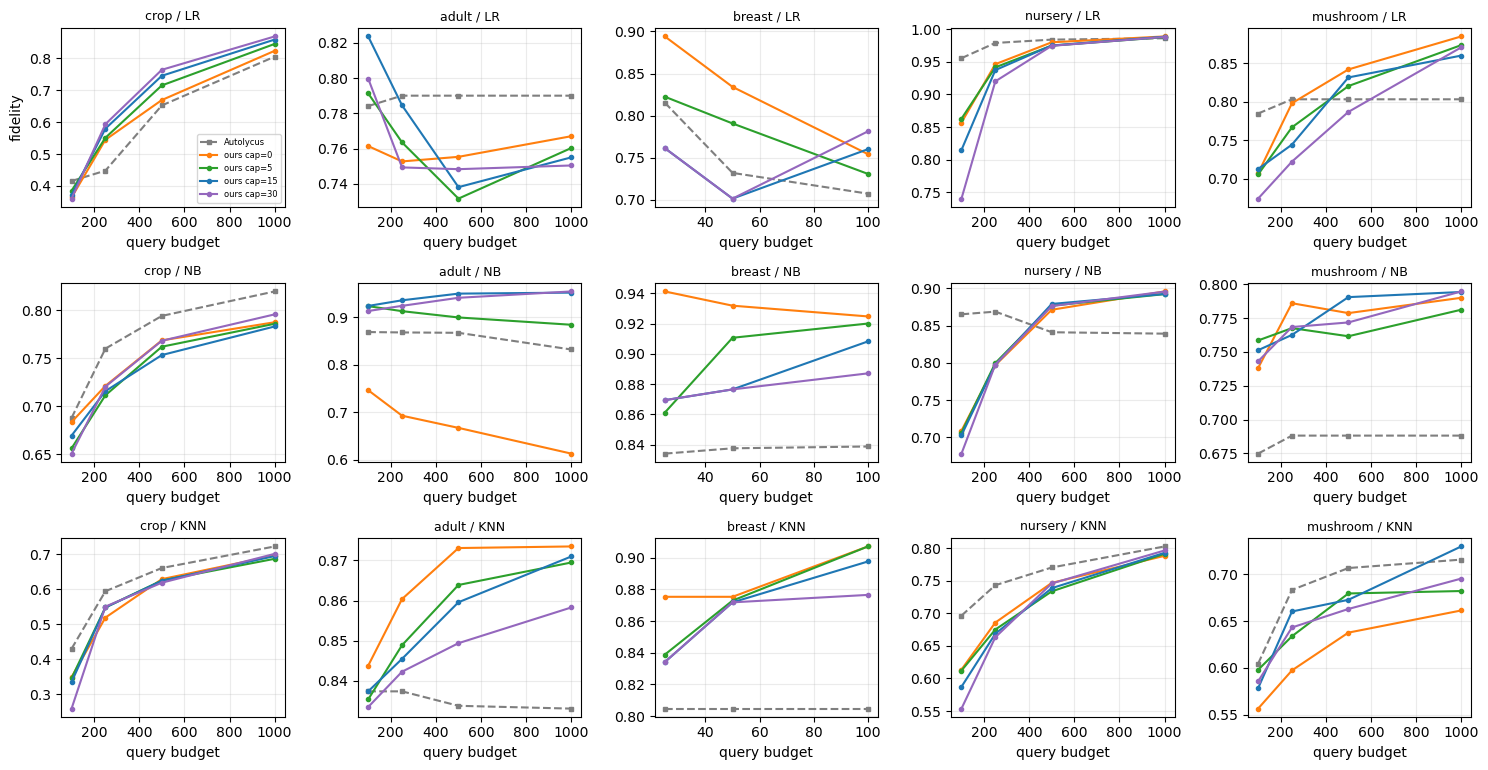

In [6]:
def plot_cell(r, ax=None):
    disp = MODEL_DISP.get(r['model'], r['model'].upper())
    own = ax is not None
    if not own:
        fig, ax = plt.subplots(figsize=(4.2, 3.2))
    xb = np.array(r['q_cap'], float)   # query BUDGET on the x-axis (Autolycus convention)
    b = r['base']
    ax.plot(xb, b['fid_mean'], '--', color='tab:gray', marker='s', ms=3, label='Autolycus')
    for c in r['div_caps']:
        o = r['ours'][str(c)]
        ax.plot(xb, o['fid_mean'], '-', color=CAP_COLORS.get(c, 'tab:blue'),
                marker='o', ms=3, label=f'ours cap={c}')
    ax.set_title(f"{r['dataset']} / {disp}", fontsize=9)
    ax.set_xlabel('query budget'); ax.set_ylabel('fidelity'); ax.grid(alpha=0.25); ax.set_ylim(0.4, 1.0)
    if not own:
        ax.legend(fontsize=7); plt.tight_layout()
        fig.savefig(FIG_DIR / f"{r['dataset']}_{disp}.png", dpi=140); plt.close(fig)

for r in sweep:
    plot_cell(r)
print('saved', len(sweep), 'curves to', FIG_DIR)

hd = {(MODEL_DISP.get(r['model'], r['model'].upper()), r['dataset']): r for r in sweep}
ncol = len(DATASET_ORDER); nrow = len(HEADLINE)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.6 * nrow), squeeze=False)
for i, mdl in enumerate(HEADLINE):
    for j, ds in enumerate(DATASET_ORDER):
        ax = axes[i][j]; r = hd.get((mdl, ds))
        if r:
            plot_cell(r, ax=ax)
        else:
            ax.axis('off')
        if not (i == 0 and j == 0):
            ax.set_ylabel('')
axes[0][0].legend(fontsize=6, loc='lower right')
plt.tight_layout(); fig.savefig(FIG_DIR / 'grid_headline.png', dpi=140); plt.show()

## 6. Paper figure — ours vs Autolycus (standard-error band)

Two lines per panel: **ours** (at a single **fixed** diverse budget `DIV_CAP_FIXED`, not per-cell
tuned) and **Autolycus**, each with a **standard-error band** (std/√10) over the seed sets. SE (not
min--max) because the comparison is paired: it reflects how well the mean is estimated, whereas
min--max is dominated by seed-to-seed swings that move both arms together. Saved to `clean_grid.png`.

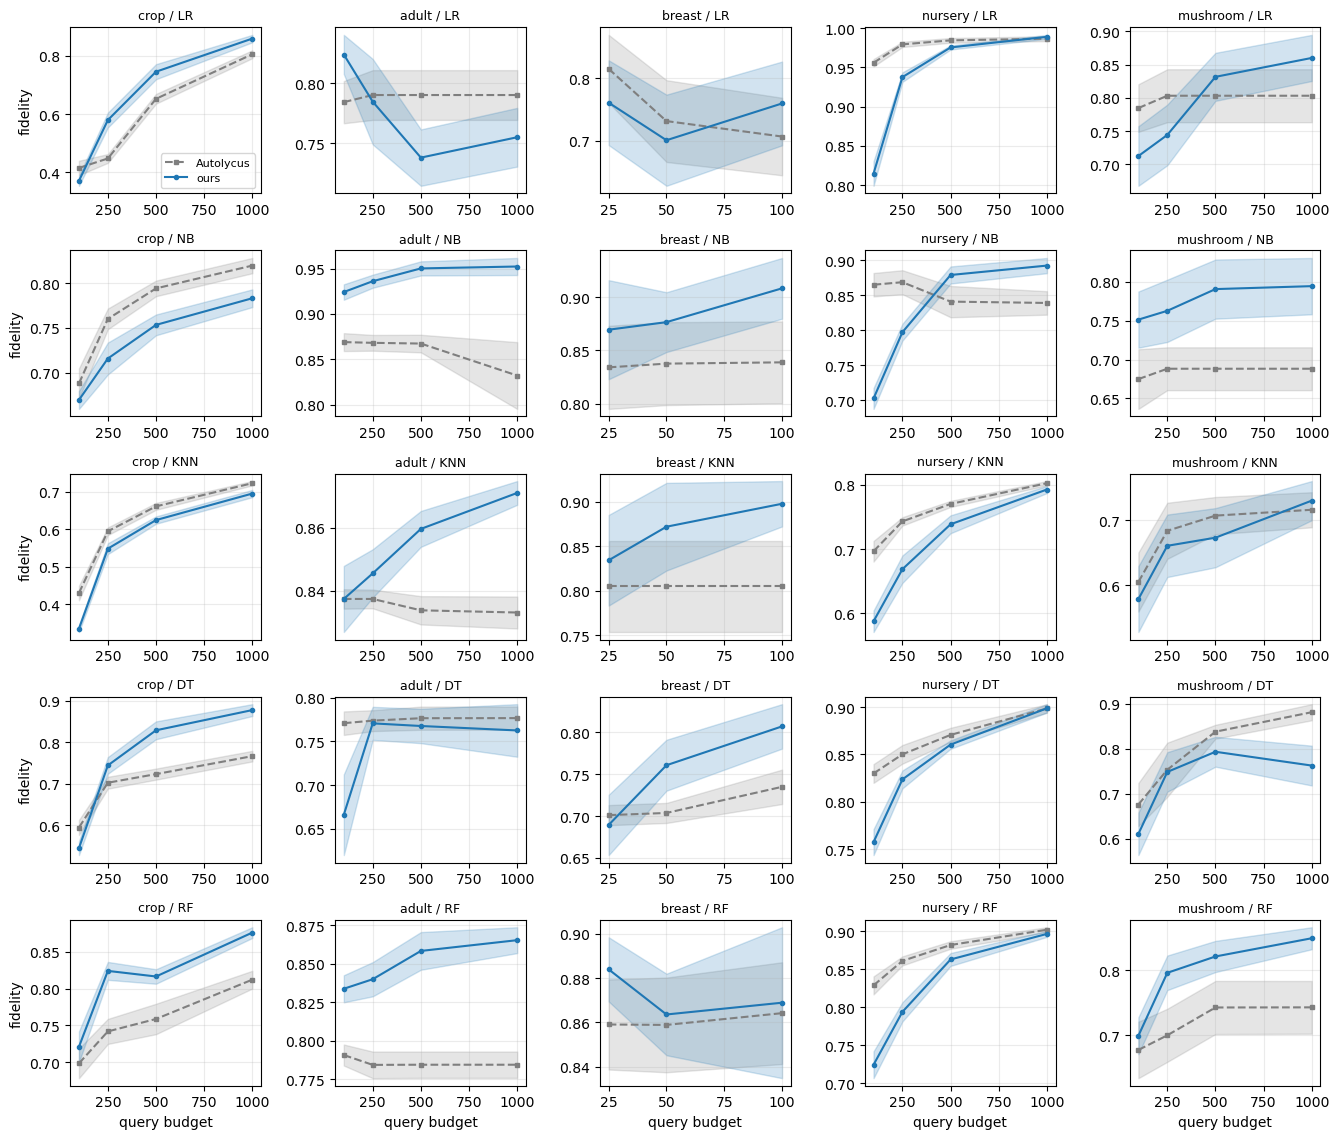

In [7]:
def _se(all_by_q):
    return np.array([np.std(v) / np.sqrt(len(v)) if len(v) else 0.0 for v in all_by_q])

def plot_clean(r, ax):
    xb = np.array(r['q_cap'], float)
    o = r['ours'][str(DIV_CAP_FIXED)]                  # fixed diverse budget (no per-cell tuning)
    om = np.array(o['fid_mean']); o_se = _se(o['fid_all'])
    b = r['base']; bm = np.array(b['fid_mean']); b_se = _se(b['fid_all'])
    ax.plot(xb, bm, '--', color='tab:gray', marker='s', ms=3, label='Autolycus')
    ax.fill_between(xb, bm - b_se, bm + b_se, color='tab:gray', alpha=0.2)
    ax.plot(xb, om, '-', color='tab:blue', marker='o', ms=3, label='ours')
    ax.fill_between(xb, om - o_se, om + o_se, color='tab:blue', alpha=0.2)
    disp = MODEL_DISP.get(r['model'], r['model'].upper())
    ax.set_title(f"{r['dataset']} / {disp}", fontsize=9)
    ax.set_xlabel('query budget'); ax.set_ylabel('fidelity'); ax.grid(alpha=0.25); ax.set_ylim(0.4, 1.0)

MODELS_ALL = HEADLINE + APPENDIX
cells_by = {(MODEL_DISP.get(r['model'], r['model'].upper()), r['dataset']): r for r in sweep}
fig, axes = plt.subplots(len(MODELS_ALL), len(DATASET_ORDER),
                         figsize=(2.7 * len(DATASET_ORDER), 2.3 * len(MODELS_ALL)), squeeze=False)
for i, mdl in enumerate(MODELS_ALL):
    for j, ds in enumerate(DATASET_ORDER):
        ax = axes[i][j]; r = cells_by.get((mdl, ds))
        if r:
            plot_clean(r, ax)
        else:
            ax.axis('off')
        if j != 0:
            ax.set_ylabel('')
        if i != len(MODELS_ALL) - 1:
            ax.set_xlabel('')
axes[0][0].legend(fontsize=8, loc='lower right')
plt.tight_layout()
fig.savefig(FIG_DIR / 'clean_grid.png', dpi=150)
plt.show()